In [25]:
# imports
import os
import argparse
import time
from pathlib import Path
from typing import Tuple
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
from tqdm import tqdm
import numpy as np
import torch.optim as optim
from torchvision import datasets, transforms

# import modules
import sys
sys.path.insert(0, '../src')
import cnn_model as cnn
import dataset

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_model = cnn.ASL_CNN(num_classes=28).to(device)


In [27]:
def train_model(model, loss_fn, optimizer, scheduler, dataloader, device,
                best_model_path='best_model.pth', num_epochs=20, print_every=10):
    """ train CNN on images of letters

    Args:
        model (nn.Module): pytorch CNN model
        loss_fn: (Tensor, Tensor) -> Tensor (scalar): loss function
        optimizer (nn.optim): pytorch optimizer
        scheduler (torch.optim.lr_scheduler): pytorch learning rate scheduler
        dataloader (dict): dictionary containing the DataLoaders for 'train' and 'validation' phases num_epochs (int): number of epochs to train the model for """

    print(f"Starting training for {num_epochs} epochs")
    print(f"Train batches: {len(dataloader['train'])}")
    print(f"Validation batches: {len(dataloader['validation'])}")

    train_loss = []
    train_accuracy = []
    val_loss = []
    val_accuracy = []
    model = model.to(device)
    torch.save(model.state_dict(), best_model_path)
    best_accuracy = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
                print(f"\nTraining Phase")
            else:
                model.eval()
                print(f"\nValidation Phase")

            cumulative_loss = 0.0
            cumulative_corrects = 0
            cumulative_samples = 0
            dataset_size = len(dataloader[phase].dataset)
            num_batches = len(dataloader[phase])

            for batch_idx, (inputs, labels) in enumerate(dataloader[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, predictions = torch.max(outputs, 1)
                    batch_loss = loss_fn(outputs, labels)

                    if phase == 'train':
                        batch_loss.backward()
                        optimizer.step()

                cumulative_loss += batch_loss.item() * inputs.size(0)
                cumulative_corrects += torch.sum(predictions == labels.data)
                cumulative_samples += inputs.size(0)

                if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == num_batches:
                    current_loss = cumulative_loss / cumulative_samples
                    current_acc = cumulative_corrects.double() / cumulative_samples
                    progress = (batch_idx + 1) / num_batches * 100

                    print(f"Batch [{batch_idx + 1:4d}/{num_batches:4d}] ({progress:5.1f}%), "
                          f"Loss: {current_loss:.4f}, Accuracy: {current_acc:.4f}")

                    if phase == 'train':
                        train_loss.append(current_loss)
                        train_accuracy.append(current_acc)
                    elif phase == 'validation':
                        val_loss.append(current_loss)
                        val_accuracy.append(current_acc)


            epoch_loss = cumulative_loss / dataset_size
            epoch_accuracy = cumulative_corrects.double() / dataset_size

            if phase == 'train':
                scheduler.step()
                current_lr = scheduler.get_last_lr()[0]
                print(f"Learning rate: {current_lr:.6f}")


            print(f"\n{phase.upper()} RESULTS:")
            print(f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

            # save best model
            if phase == 'validation' and epoch_accuracy > best_accuracy:
                best_accuracy = epoch_accuracy
                torch.save(model.state_dict(), best_model_path)
                print(f"New best model saved (Accuracy: {best_accuracy:.4f})")

    print(f"Training Complete")
    print(f"Best validation accuracy: {best_accuracy:.4f}")
    print(f"Loading best model from {best_model_path}")

    model.load_state_dict(torch.load(best_model_path))
    return model, (train_loss, train_accuracy), (val_loss, val_accuracy)

In [28]:
def evaluate_model(model, loss_fn, test_dataloader, device, print_every=10):
    """ evaluate CNN on images of letters

    Args:
        model (nn.Module): pytorch CNN model
        loss_fn (Tensor, Tensor): loss function
        test_dataloader (DataLoader): the DataLoader for the test dataset

    Returns: test accuracy and loss
    """
    model = model.to(device)
    model.eval()

    cumulative_loss = 0.0
    cumulative_corrects = 0
    cumulative_samples = 0
    test_dataset_size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            batch_loss = loss_fn(outputs, labels)

            cumulative_loss += batch_loss.item() * inputs.size(0)
            cumulative_corrects += torch.sum(predictions == labels.data)
            cumulative_samples += inputs.size(0)

            if (batch_idx + 1) % print_every == 0 or (batch_idx + 1) == num_batches:
                current_loss = cumulative_loss / cumulative_samples
                current_acc = cumulative_corrects.double() / cumulative_samples
                progress = (batch_idx + 1) / num_batches * 100

                print(f"Batch [{batch_idx + 1:4d}/{num_batches:4d}] ({progress:5.1f}%), "
                      f"Loss: {current_loss:.4f}, Acc: {current_acc:.4f}")

    test_loss = cumulative_loss / test_dataset_size
    test_accuracy = cumulative_corrects.double() / test_dataset_size

    print(f"TEST RESULTS:")
    print(f"Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}")

    return test_loss, test_accuracy


# Train and Evaluate

In [29]:
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

train_dataset = datasets.ImageFolder("../letters/train", transform=transform)
val_dataset = datasets.ImageFolder("../letters/val",   transform=transform)
test_dataset = datasets.ImageFolder("../letters/test",  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

dataloaders = {"train": train_loader, "validation": val_loader}


In [30]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)


In [31]:
best_cnn, train_logs, val_logs = train_model(
    model=cnn_model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    dataloader=dataloaders,
    device=device,
    best_model_path="best_asl_cnn.pth",
    num_epochs=3,
    print_every=10
)


Starting training for 3 epochs
Train batches: 2100
Validation batches: 263
Epoch 1/3

Training Phase
Batch [  10/2100] (  0.5%), Loss: 3.3127, Accuracy: 0.0688
Batch [  20/2100] (  1.0%), Loss: 3.3258, Accuracy: 0.0531
Batch [  30/2100] (  1.4%), Loss: 3.3116, Accuracy: 0.0604
Batch [  40/2100] (  1.9%), Loss: 3.2998, Accuracy: 0.0672
Batch [  50/2100] (  2.4%), Loss: 3.2771, Accuracy: 0.0838
Batch [  60/2100] (  2.9%), Loss: 3.2555, Accuracy: 0.0969
Batch [  70/2100] (  3.3%), Loss: 3.2257, Accuracy: 0.1152
Batch [  80/2100] (  3.8%), Loss: 3.1891, Accuracy: 0.1281
Batch [  90/2100] (  4.3%), Loss: 3.1417, Accuracy: 0.1493
Batch [ 100/2100] (  4.8%), Loss: 3.0991, Accuracy: 0.1594
Batch [ 110/2100] (  5.2%), Loss: 3.0433, Accuracy: 0.1756
Batch [ 120/2100] (  5.7%), Loss: 2.9929, Accuracy: 0.1906
Batch [ 130/2100] (  6.2%), Loss: 2.9324, Accuracy: 0.2072
Batch [ 140/2100] (  6.7%), Loss: 2.8752, Accuracy: 0.2188
Batch [ 150/2100] (  7.1%), Loss: 2.8149, Accuracy: 0.2346
Batch [ 160/21

In [32]:
test_loss, test_acc = evaluate_model(best_cnn, loss_fn, test_loader, device)
print("CNN Test Accuracy:", test_acc)

Batch [  10/ 263] (  3.8%), Loss: 0.0027, Acc: 1.0000
Batch [  20/ 263] (  7.6%), Loss: 0.0090, Acc: 0.9969
Batch [  30/ 263] ( 11.4%), Loss: 0.0061, Acc: 0.9979
Batch [  40/ 263] ( 15.2%), Loss: 0.0059, Acc: 0.9984
Batch [  50/ 263] ( 19.0%), Loss: 0.0048, Acc: 0.9988
Batch [  60/ 263] ( 22.8%), Loss: 0.0057, Acc: 0.9990
Batch [  70/ 263] ( 26.6%), Loss: 0.0084, Acc: 0.9982
Batch [  80/ 263] ( 30.4%), Loss: 0.0158, Acc: 0.9969
Batch [  90/ 263] ( 34.2%), Loss: 0.0171, Acc: 0.9965
Batch [ 100/ 263] ( 38.0%), Loss: 0.0159, Acc: 0.9969
Batch [ 110/ 263] ( 41.8%), Loss: 0.0158, Acc: 0.9966
Batch [ 120/ 263] ( 45.6%), Loss: 0.0147, Acc: 0.9969
Batch [ 130/ 263] ( 49.4%), Loss: 0.0138, Acc: 0.9971
Batch [ 140/ 263] ( 53.2%), Loss: 0.0136, Acc: 0.9973
Batch [ 150/ 263] ( 57.0%), Loss: 0.0136, Acc: 0.9971
Batch [ 160/ 263] ( 60.8%), Loss: 0.0131, Acc: 0.9973
Batch [ 170/ 263] ( 64.6%), Loss: 0.0183, Acc: 0.9967
Batch [ 180/ 263] ( 68.4%), Loss: 0.0185, Acc: 0.9965
Batch [ 190/ 263] ( 72.2%), 

In [39]:
all_preds, all_labels = [], []
best_cnn.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_cnn(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

<Figure size 1400x1400 with 0 Axes>

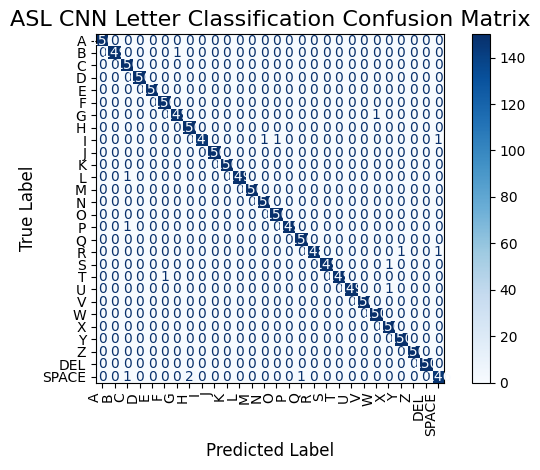

In [40]:
# A-Z, SPACE, DEL
class_labels = [chr(i) for i in range(ord('A'), ord('Z')+1)] + ['DEL', 'SPACE']

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
plt.figure(figsize=(14, 14))
disp.plot(cmap="Blues")
plt.title("ASL CNN Letter Classification Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.savefig("../cnn_letter_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def plot_training_history_per_batch(train_metrics, val_metrics):
    """ plot training and validation loss and accuracy over batches

    Args:
        train_metrics (tuple): (train_loss, train_accuracy)
        val_metrics (tuple): (val_loss, val_accuracy)
    """
    train_loss, train_acc = train_metrics
    val_loss, val_acc = val_metrics

    plt.figure(figsize=(12, 5))

    # plot loss
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, 'b-', label='Train Loss')
    plt.plot(val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss per Batch')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot([float(a) for a in train_acc], 'b-', label='Train Accuracy')
    plt.plot([float(a) for a in val_acc], 'r-', label='Validation Accuracy')
    plt.title('CNN Letter Training and Validation Accuracy per Batch')
    plt.xlabel('Batch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


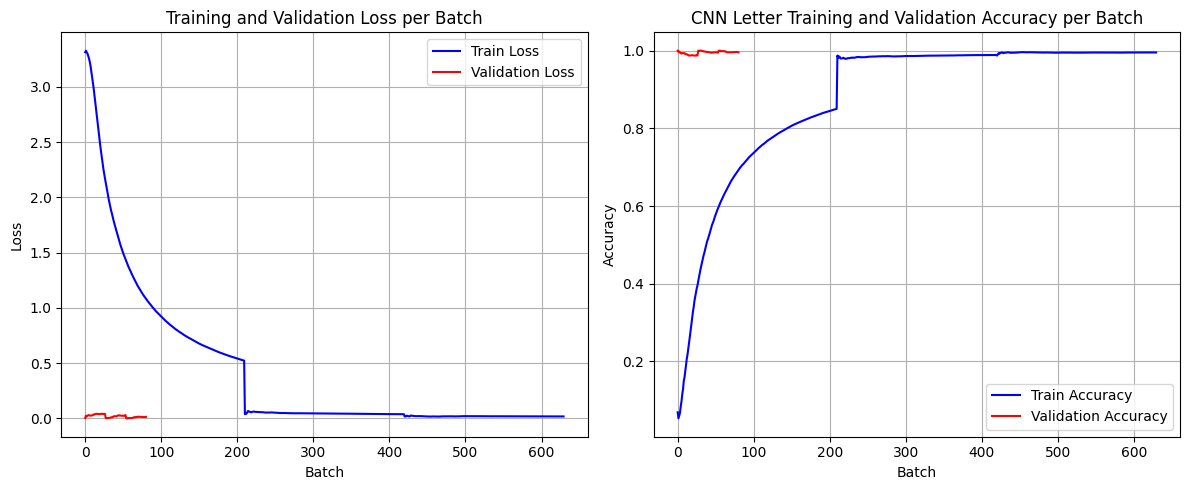

In [42]:
plot_training_history_per_batch(train_logs, val_logs)